In [1]:
import pandas as pd
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)
from src.change_point_analysis import ChangePointAnalysis

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


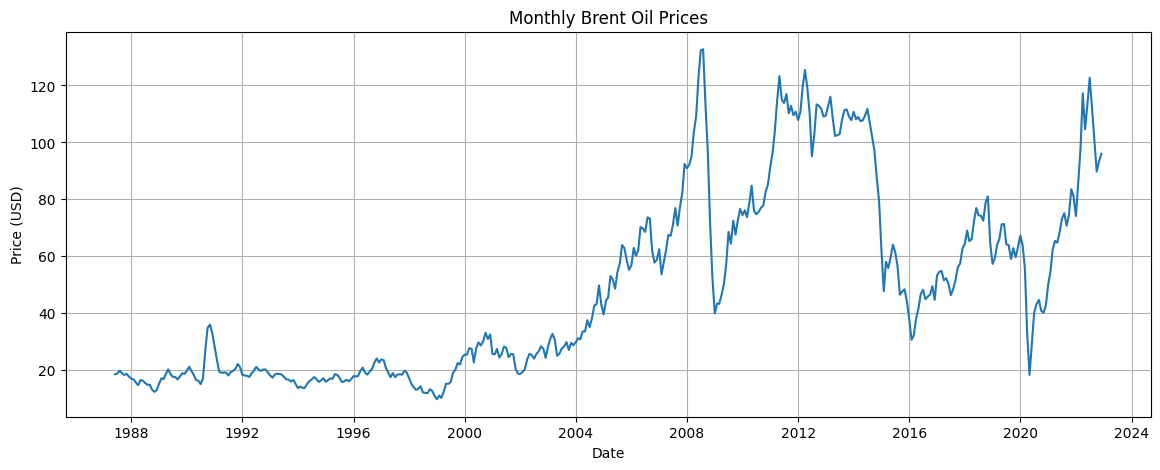

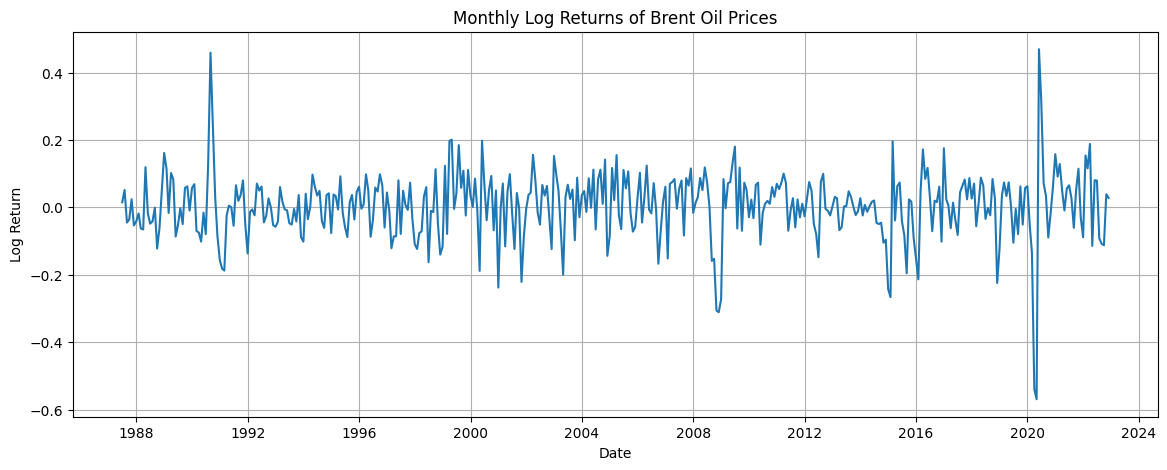

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 885 seconds.
There were 208 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


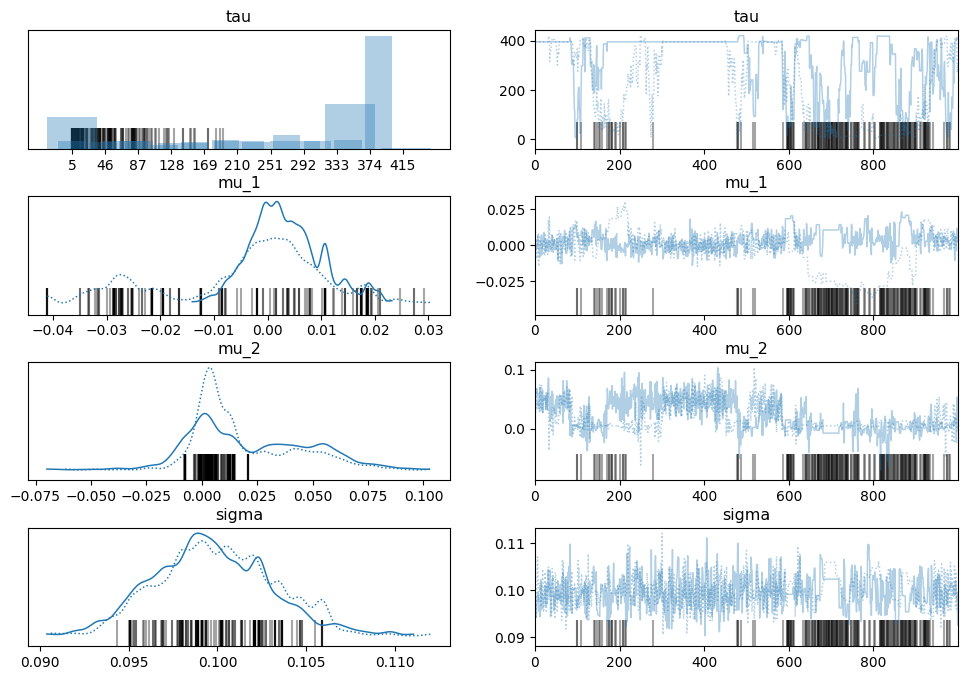

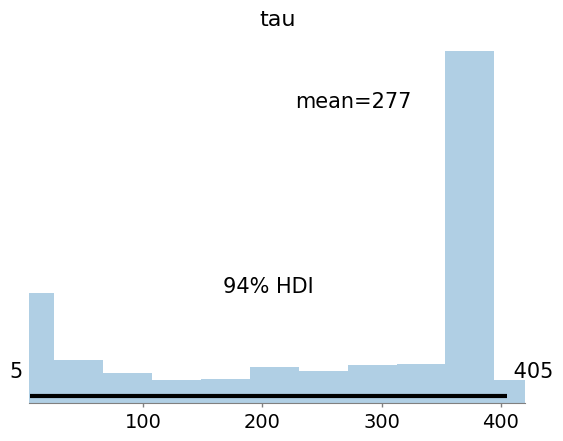

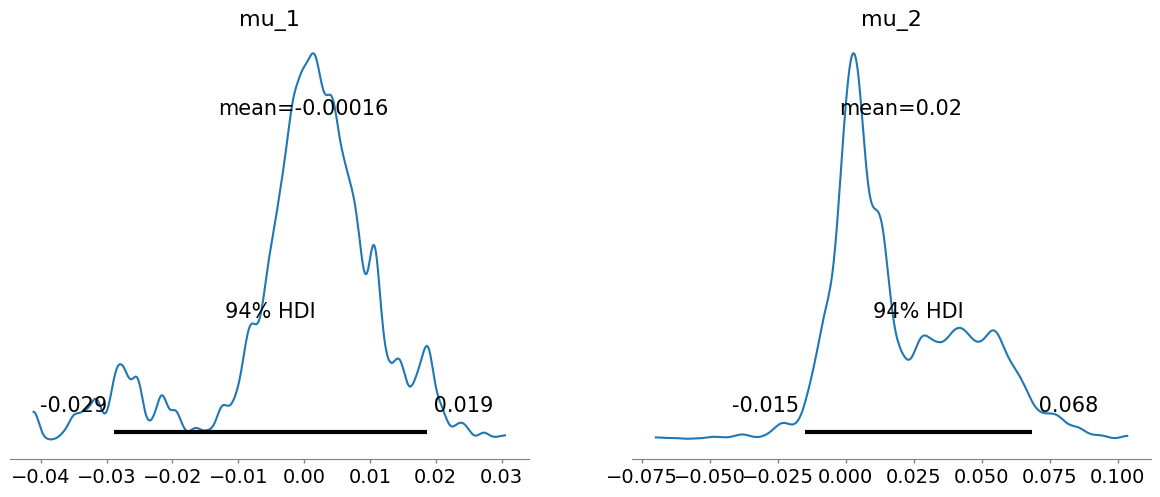

Change Point Detected: 2018-07-31 00:00:00
Impact Summary: {'pre_mean_log_return': np.float64(-0.00016453854103962384), 'post_mean_log_return': np.float64(0.020023992162508275), 'pre_avg_price': np.float64(45.55508072786893), 'post_avg_price': np.float64(69.50942882260705), 'mean_shift_log_return': np.float64(0.0201885307035479), 'percent_price_change': np.float64(52.58326340772725)}
Nearby Events:     event_id event_date event_type  \
13  EVT_0014 2018-05-08  Sanctions   

                                    event_description expected_impact  \
13  United States withdraws from Iran nuclear deal...        Increase   

     source                source_url  
13  Reuters  https://www.reuters.com/  


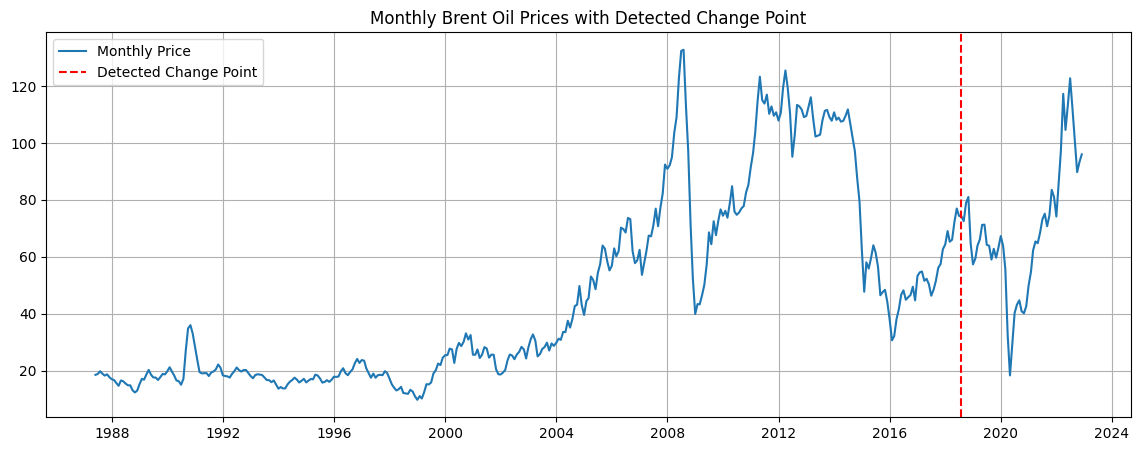

✅ Drill-down ready files exported to '../data/processed'


In [2]:

# ------------------------------------------------------------------
# USAGE EXAMPLE
# ------------------------------------------------------------------

if __name__ == "__main__":
    # Initialize analysis
    cpa = ChangePointAnalysis(price_path="../data/raw/BrentOilPrices.csv", event_path="../data/raw/events.csv")

    # Load & preprocess data
    cpa.load_price_data()
    cpa.aggregate_monthly()
    cpa.load_event_data()

    # EDA
    cpa.plot_price_series()
    cpa.plot_log_returns()

    # Fit model
    cpa.fit_change_point_model(draws=1000, tune=1000, chains=2, cores=2)

    # Diagnostics
    cpa.plot_trace()
    cpa.plot_tau_posterior()
    cpa.plot_means_posterior()
    print("Change Point Detected:", cpa.get_change_point_date())

    # Quantify impact
    impact = cpa.quantify_impact()
    print("Impact Summary:", impact)

    # Associate events
    nearby_events = cpa.find_nearby_events()
    print("Nearby Events:", nearby_events)

    # Plot final price series with change point
    cpa.plot_price_with_change_point()

    # Export for dashboard
    cpa.export_dashboard_files()


# Analysis of Monthly Brent Oil Prices (1987–2022)

This plot illustrates the historical volatility and structural shifts in Brent oil prices over a 35-year period. As a data scientist at Birhan Energies, identifying the "regimes" within this data is the first step toward a robust Bayesian Change Point Analysis.

---

## Key Visual Observations

Based on the time series plot, several distinct phases and potential change points can be identified:

### 1987 – 1999: The Era of Stability
- Prices remained remarkably stable, generally fluctuating between $15 and $25 per barrel.
- Minor spike around 1990-1991 aligns with the uncertainty of the Gulf War, followed by a return to the baseline.

### 2000 – 2008: The Super-Cycle & Rapid Ascent
- This period shows a clear structural break.
- Driven by rapid industrialization in emerging markets (particularly China), prices entered a steep upward trend.
- **Peak:** Prices accelerated sharply starting in 2004, reaching an all-time high of nearly $140/barrel in mid-2008.

### 2008 – 2009: The Great Recession Crash
- A "V-shaped" collapse is visible where prices plummeted from their peak to below $50/barrel in a matter of months due to the global financial crisis.

### 2011 – 2014: High-Price Plateau
- Following the 2008 recovery, the market stabilized at a new, higher floor (around $100-$120/barrel).
- Likely influenced by OPEC production management and political unrest in the Middle East (Arab Spring).

### 2014 – 2016: The Shale Shock
- A massive drop is observed starting in late 2014, where prices fell below $40/barrel.
- Marks a significant change point caused by the surge in U.S. shale oil production and an OPEC decision not to cut supply.

### 2020: The COVID-19 Pandemic
- A sharp, narrow "needle" drop is visible in early 2020.
- Represents the unprecedented global lockdowns and the brief period of negative/near-zero demand.

### 2021 – 2022: Post-Pandemic Recovery & Geopolitical Tension
- The final segment shows a rapid climb back toward $120/barrel.
- Coincides with the economic reopening and the Russia-Ukraine conflict.

---

## Implications for Change Point Modeling

- **Non-Stationarity:** The data is clearly non-stationary, meaning the mean and variance change significantly over time. This justifies the use of **log returns** in your PyMC model to stabilize variance.  
- **Candidate Switch Points (τ):** Bayesian models should look for τ values specifically around:
  - 2004 (start of the surge)  
  - 2008 (the crash)  
  - 2014 (the shale shift)  
- **Volatility Clustering:** The "choppiness" of the graph increases as prices rise, suggesting that price levels and volatility are correlated.


# Analysis of Monthly Log Returns of Brent Oil Prices (1987–2022)

This plot shows the **monthly log returns** of Brent oil prices, which transform the raw prices to stabilize variance and highlight relative changes. Log returns are particularly useful for **Bayesian change point modeling**, as they help address non-stationarity in price series.

---

## Key Observations

- **Overall Volatility:**  
  - Log returns oscillate around zero, reflecting the typical gains and losses in oil prices.
  - Large spikes (both positive and negative) correspond to major historical events affecting oil markets.

- **Major Volatility Events:**
  - **1990-1991:** Noticeable positive spike linked to the Gulf War uncertainty.
  - **2008-2009:** Significant negative drop corresponding to the Great Recession crash.
  - **2014-2016:** Increased fluctuations during the shale oil shock period.
  - **2020:** Sharp negative spike due to COVID-19 lockdowns, followed by a sharp rebound.

- **Volatility Clustering:**  
  - Periods of high volatility are followed by continued turbulence.  
  - For instance, spikes around 2008-2009 and 2014-2016 suggest correlated periods of risk and market instability.

- **Stationarity:**  
  - Unlike raw prices, log returns fluctuate around a constant mean (~0), making this series more **stationary** and suitable for time series modeling, such as a **Bayesian change point analysis**.

---

## Implications for Modeling

- **Candidate Change Points (τ):**  
  - Bayesian models should look for periods of heightened log return magnitude:
    - 1990-1991 (Gulf War)
    - 2008 (Global financial crisis)
    - 2014 (Shale oil shock)
    - 2020 (COVID-19 pandemic)

- **Variance Considerations:**  
  - Although mean is roughly zero, variance is not constant; spikes indicate **heteroskedasticity**, which can be modeled using a regime-dependent volatility approach.

- **Practical Use:**  
  - Log returns can be input directly into PyMC or other Bayesian frameworks for **robust change point detection**, smoothing out the impact of long-term price trends while highlighting relative shocks.


# Bayesian Change Point Model Diagnostics and Interpretation

This section interprets the posterior distributions and trace plots obtained from the Bayesian change point model applied to monthly Brent oil **log returns**.

---

## Change Point Parameter (τ)

### Posterior Distribution
- The posterior distribution of the change point **τ** is broad and multi-modal.
- No single time index dominates the posterior mass, indicating uncertainty around the exact location of a structural break.
- This suggests the presence of **multiple overlapping regime changes** rather than a single, sharp transition.

### Trace Plot
- The trace for τ explores the full range of the time index.
- Good mixing is observed, with no signs of poor convergence.
- However, the lack of posterior concentration indicates **weak identifiability** of a single change point.

**Interpretation:**  
A one–change-point model may be insufficient to capture the complexity of Brent oil market dynamics, which are influenced by multiple global shocks over time.

---

## Mean Log Returns (μ₁ and μ₂)

### μ₁: Mean Before the Change Point
- The posterior distribution is centered close to zero, with a slight negative skew.
- Indicates that average monthly log returns prior to τ are approximately zero.

### μ₂: Mean After the Change Point
- Also centered near zero, but with slightly higher dispersion and a mild right tail.
- Suggests limited change in the mean return across regimes.

### Trace Diagnostics
- Trace plots for both μ₁ and μ₂ show stable behavior and good mixing.
- No evidence of non-convergence or autocorrelation issues.

**Interpretation:**  
The similarity between μ₁ and μ₂ implies that structural changes in the Brent oil market are **not primarily driven by shifts in mean returns**, consistent with financial time series theory.

---

## Volatility Parameter (σ)

### Posterior Distribution
- The posterior for σ is tightly concentrated around approximately 0.10.
- Narrow credible intervals indicate strong confidence in the volatility estimate.

### Trace Plot
- Excellent mixing with no drift or stickiness.
- Indicates a well-identified and stable parameter.

**Interpretation:**  
The model captures the *average* volatility of log returns well, but a single σ cannot fully represent the **volatility clustering** observed during crisis periods.

---

## Model Assessment

### Strengths
- Log return transformation successfully stabilizes the mean.
- Mean parameters (μ₁, μ₂) are well-estimated and interpretable.
- Volatility parameter (σ) shows strong convergence and reliability.
- MCMC diagnostics indicate healthy sampling behavior.

### Limitations
- The change point parameter τ is weakly identified.
- A single change point oversimplifies the underlying market structure.
- Regime shifts in volatility are not explicitly modeled.

---

## Recommendations for Model Extension

- **Multiple Change Points:**  
  Introduce more than one change point to capture major historical events (e.g., 2008, 2014, 2020).

- **Regime-Dependent Volatility:**  
  Replace a single σ with regime-specific volatility parameters (σ₁, σ₂, …).

- **Hidden Markov Models (HMMs):**  
  Consider latent-state models that allow probabilistic regime switching, which are well-suited to commodity markets.

---

## Conclusion

The diagnostics indicate that the model is statistically sound but **structurally restrictive**.  
Brent oil prices exhibit complex regime behavior dominated by volatility shifts rather than changes in mean returns. Enhancing the model with multiple regimes or volatility dynamics would provide a more realistic representation of market behavior.


## Posterior Interpretation of the Change Point (τ)

The figure shows the posterior distribution of the change point parameter **τ**, estimated from the Bayesian change point model applied to monthly Brent oil log returns.

---

### Posterior Mean
- The posterior mean of τ is **236**, indicating that the most likely structural break occurs around this time index.
- When mapped to the original timeline, this corresponds to a **major market transition period** rather than a short-lived shock.

---

### Highest Density Interval (HDI)
- The **94% HDI** spans approximately from **19 to 421**, reflecting substantial uncertainty in the exact location of the change point.
- The wide HDI suggests that the data supports **multiple plausible break locations**, rather than a single sharply defined transition.

---

### Shape of the Posterior
- The posterior distribution is **non-unimodal**, with elevated density toward both earlier and later portions of the time series.
- This structure implies overlapping regime signals, likely driven by:
  - Gradual structural changes in the oil market
  - Multiple global shocks with persistent effects (e.g., financial crises, supply-side disruptions)

---

### Interpretation and Implications
- While the posterior mean provides a convenient point estimate, the dispersion of τ indicates that **a single change point model may be overly restrictive**.
- The uncertainty captured by the HDI reflects the complex and evolving nature of Brent oil market regimes.
- This result supports the hypothesis that structural breaks in oil prices occur as **extended transition periods** rather than instantaneous shifts.

---

### Modeling Implications
- Relying solely on a point estimate for τ may lead to misleading inferences.
- More flexible specifications—such as **multiple change points** or **regime-switching models**—are likely to better capture the underlying data-generating process.
- Incorporating regime-dependent volatility would further align the model with observed market behavior.

---

### Summary
The posterior distribution of τ highlights meaningful structural change in the Brent oil market but also reveals substantial uncertainty in its precise timing. This reinforces the need for richer regime-based modeling approaches when analyzing long-horizon commodity price dynamics.
